# 01. Data Integration & Strategic Labeling

In this notebook, we load and integrate the Dunnhumby dataset. This robust dataset consists of multiple tables including household demographics, products, campaigns, coupons, and longitudinal transaction data. We will begin by importing these parquet files to lay the groundwork for our data transformation and churn labeling strategy.

In [46]:
import pandas as pd
import numpy as np

# Define base path for the data (matching the change_parquet.py script output)
data_path = '../Data/Raw/'

# Load all 8 parquet files
transaction_data = pd.read_parquet(f'{data_path}transaction_data.parquet')
hh_demographic = pd.read_parquet(f'{data_path}hh_demographic.parquet')
product = pd.read_parquet(f'{data_path}product.parquet')
campaign_table = pd.read_parquet(f'{data_path}campaign_table.parquet')
campaign_desc = pd.read_parquet(f'{data_path}campaign_desc.parquet')
coupon = pd.read_parquet(f'{data_path}coupon.parquet')
coupon_redempt = pd.read_parquet(f'{data_path}coupon_redempt.parquet')
causal_data = pd.read_parquet(f'{data_path}causal_data.parquet')

print('Successfully loaded 8 parquet datasets!')

Successfully loaded 8 parquet datasets!


In [47]:
# Store dataframes in a dictionary for easy iteration
datasets = {
    'transaction_data': transaction_data, 'hh_demographic': hh_demographic, 'product': product,
    'campaign_table': campaign_table, 'campaign_desc': campaign_desc, 'coupon': coupon,
    'coupon_redempt': coupon_redempt, 'causal_data': causal_data
}


for name, df in datasets.items():
    separator = '-' * 40
    print(f'\n{separator}')
    print(f"TABLE: {name.upper()}")
    print(f'{separator}')
    print(f'Shape: {df.shape}\n')
    df.info()
    print('\nFirst 3 rows:')
    display(df.head(3))
    print('\n')


----------------------------------------
TABLE: TRANSACTION_DATA
----------------------------------------
Shape: (2595732, 12)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2595732 entries, 0 to 2595731
Data columns (total 12 columns):
 #   Column             Dtype  
---  ------             -----  
 0   household_key      int16  
 1   BASKET_ID          int64  
 2   DAY                int16  
 3   PRODUCT_ID         int32  
 4   QUANTITY           int32  
 5   SALES_VALUE        float32
 6   STORE_ID           int32  
 7   RETAIL_DISC        float32
 8   TRANS_TIME         int16  
 9   WEEK_NO            int8   
 10  COUPON_DISC        float32
 11  COUPON_MATCH_DISC  float32
dtypes: float32(4), int16(3), int32(3), int64(1), int8(1)
memory usage: 106.4 MB

First 3 rows:


,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,2375,26984851472,1,1004906,1,1.39,364,-0.6,1631,1,0.0,0.0
1,2375,26984851472,1,1033142,1,0.82,364,0.0,1631,1,0.0,0.0
2,2375,26984851472,1,1036325,1,0.99,364,-0.3,1631,1,0.0,0.0





----------------------------------------
TABLE: HH_DEMOGRAPHIC
----------------------------------------
Shape: (801, 8)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   AGE_DESC             801 non-null    object
 1   MARITAL_STATUS_CODE  801 non-null    object
 2   INCOME_DESC          801 non-null    object
 3   HOMEOWNER_DESC       801 non-null    object
 4   HH_COMP_DESC         801 non-null    object
 5   HOUSEHOLD_SIZE_DESC  801 non-null    object
 6   KID_CATEGORY_DESC    801 non-null    object
 7   household_key        801 non-null    int16 
dtypes: int16(1), object(7)
memory usage: 45.5+ KB

First 3 rows:


,AGE_DESC,MARITAL_STATUS_CODE,INCOME_DESC,HOMEOWNER_DESC,HH_COMP_DESC,HOUSEHOLD_SIZE_DESC,KID_CATEGORY_DESC,household_key
0,65+,A,35-49K,Homeowner,2 Adults No Kids,2,None/Unknown,1
1,45-54,A,50-74K,Homeowner,2 Adults No Kids,2,None/Unknown,7
2,25-34,U,25-34K,Unknown,2 Adults Kids,3,1,8





----------------------------------------
TABLE: PRODUCT
----------------------------------------
Shape: (92353, 7)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92353 entries, 0 to 92352
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   PRODUCT_ID            92353 non-null  int32 
 1   MANUFACTURER          92353 non-null  int16 
 2   DEPARTMENT            92353 non-null  object
 3   BRAND                 92353 non-null  object
 4   COMMODITY_DESC        92353 non-null  object
 5   SUB_COMMODITY_DESC    92353 non-null  object
 6   CURR_SIZE_OF_PRODUCT  92353 non-null  object
dtypes: int16(1), int32(1), object(5)
memory usage: 4.1+ MB

First 3 rows:


...

,COUPON_UPC,PRODUCT_ID,CAMPAIGN
0,10000089061,27160,4
1,10000089064,27754,9
2,10000089073,28897,12





----------------------------------------
TABLE: COUPON_REDEMPT
----------------------------------------
Shape: (2318, 4)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2318 entries, 0 to 2317
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   household_key  2318 non-null   int16
 1   DAY            2318 non-null   int16
 2   COUPON_UPC     2318 non-null   int64
 3   CAMPAIGN       2318 non-null   int8 
dtypes: int16(2), int64(1), int8(1)
memory usage: 29.6 KB

First 3 rows:


,household_key,DAY,COUPON_UPC,CAMPAIGN
0,1,421,10000085364,8
1,1,421,51700010076,8
2,1,427,54200000033,8





----------------------------------------
TABLE: CAUSAL_DATA
----------------------------------------
Shape: (36786524, 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36786524 entries, 0 to 36786523
Data columns (total 5 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   PRODUCT_ID  int32 
 1   STORE_ID    int32 
 2   WEEK_NO     int8  
 3   display     object
 4   mailer      object
dtypes: int32(2), int8(1), object(2)
memory usage: 877.1+ MB

First 3 rows:


,PRODUCT_ID,STORE_ID,WEEK_NO,display,mailer
0,26190,286,70,0,A
1,26190,288,70,0,A
2,26190,289,70,0,A


## Step 1: Data Sanity Check & Basic Statistics

In [48]:
# Summary statistics for key numeric columns
cols_to_describe = ['QUANTITY', 'SALES_VALUE', 'RETAIL_DISC', 'COUPON_DISC']
print("Basic Statistics for Key Columns:")
display(transaction_data[cols_to_describe].describe())

# Anomaly checking
total_rows = len(transaction_data)
anomalous_sales = (transaction_data['SALES_VALUE'] <= 0).sum()
anomalous_qty = (transaction_data['QUANTITY'] <= 0).sum()
anomalous_both = ((transaction_data['SALES_VALUE'] <= 0) | (transaction_data['QUANTITY'] <= 0)).sum()

# Calculate the percentage
perc_anomalous = (anomalous_both / total_rows) * 100

print("\n--- Data Sanity Check ---")
print(f"Total rows in transaction_data: {total_rows:,}")
print(f"Rows with SALES_VALUE <= 0: {anomalous_sales:,}")
print(f"Rows with QUANTITY <= 0: {anomalous_qty:,}")
print(f"Total anomalous rows (SALES_VALUE <= 0 OR QUANTITY <= 0): {anomalous_both:,}")
print(f"Percentage of anomalous rows: {perc_anomalous:.4f}%")

Basic Statistics for Key Columns:


,QUANTITY,SALES_VALUE,RETAIL_DISC,COUPON_DISC
count,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06
mean,1.004286e+02,3.104120e+00,-5.387055e-01,-1.641601e-02
std,1.153436e+03,4.182274e+00,1.249191e+00,2.168410e-01
min,0.000000e+00,0.000000e+00,-1.800000e+02,-5.593000e+01
25%,1.000000e+00,1.290000e+00,-6.900000e-01,0.000000e+00
50%,1.000000e+00,2.000000e+00,-1.000000e-02,0.000000e+00
75%,1.000000e+00,3.490000e+00,0.000000e+00,0.000000e+00
max,8.963800e+04,8.400000e+02,3.990000e+00,0.000000e+00



--- Data Sanity Check ---
Total rows in transaction_data: 2,595,732
Rows with SALES_VALUE <= 0: 18,850
Rows with QUANTITY <= 0: 14,466
Total anomalous rows (SALES_VALUE <= 0 OR QUANTITY <= 0): 18,917
Percentage of anomalous rows: 0.7288%


In [49]:
print("--- Dimension Tables Duplicates Check ---")
product_unique = product['PRODUCT_ID'].is_unique
hh_unique = hh_demographic['household_key'].is_unique
print(f"Are PRODUCT_ID strictly unique in product table? {product_unique}")
print(f"Are household_key strictly unique in hh_demographic table? {hh_unique}")

print("\n--- Orphan Check: Campaign vs Transactions ---")
campaign_hh = set(campaign_table['household_key'].unique())
txn_hh = set(transaction_data['household_key'].unique())
orphan_hh = campaign_hh - txn_hh
print(f"Number of households in campaign_table NOT in transaction_data: {len(orphan_hh)}")

print("\n--- Causal Data Audit ---")
print("Missing values in causal_data:\n", causal_data.isnull().sum())
min_week, max_week = causal_data['WEEK_NO'].min(), causal_data['WEEK_NO'].max()
print(f"\ncausal_data WEEK_NO Range: Min = {min_week}, Max = {max_week}")

--- Dimension Tables Duplicates Check ---
Are PRODUCT_ID strictly unique in product table? True
Are household_key strictly unique in hh_demographic table? True

--- Orphan Check: Campaign vs Transactions ---
Number of households in campaign_table NOT in transaction_data: 0

--- Causal Data Audit ---
Missing values in causal_data:
 PRODUCT_ID    0
STORE_ID      0
WEEK_NO       0
display       0
mailer        0
dtype: int64

causal_data WEEK_NO Range: Min = 9, Max = 101


In [50]:
print("--- Marketing Ecosystem Sanity Check ---")

# 1. campaign_desc Check
invalid_campaigns = (campaign_desc['START_DAY'] >= campaign_desc['END_DAY']).sum()
print(f"Campaigns with START_DAY >= END_DAY: {invalid_campaigns}")

# 2. coupon Orphan Check
coupon_products = set(coupon['PRODUCT_ID'].unique())
master_products = set(product['PRODUCT_ID'].unique())
orphan_products = coupon_products - master_products
print(f"\nPRODUCT_IDs in coupon table NOT in product table: {len(orphan_products)}")

# 3. coupon_redempt Orphan Check
redempt_hhs = set(coupon_redempt['household_key'].unique())
txn_hhs = set(transaction_data['household_key'].unique())
orphan_redempt_hhs = redempt_hhs - txn_hhs
print(f"\nhousehold_keys in coupon_redempt NOT in transaction_data: {len(orphan_redempt_hhs)}")

redempt_upcs = set(coupon_redempt['COUPON_UPC'].unique())
coupon_upcs = set(coupon['COUPON_UPC'].unique())
orphan_redempt_upcs = redempt_upcs - coupon_upcs
print(f"COUPON_UPCs in coupon_redempt NOT in coupon table: {len(orphan_redempt_upcs)}")

--- Marketing Ecosystem Sanity Check ---
Campaigns with START_DAY >= END_DAY: 0

PRODUCT_IDs in coupon table NOT in product table: 0

household_keys in coupon_redempt NOT in transaction_data: 0
COUPON_UPCs in coupon_redempt NOT in coupon table: 0


In [51]:
print("--- Returns & Free Items Investigation ---")

# 1. Investigate negative SALES_VALUE
negative_sales = transaction_data[transaction_data['SALES_VALUE'] < 0]
print(f"Rows with SALES_VALUE < 0: {len(negative_sales)}")

if len(negative_sales) > 0:
    pos_sales = transaction_data[transaction_data['SALES_VALUE'] > 0]
    merged = pd.merge(
        negative_sales[['household_key', 'PRODUCT_ID', 'DAY']], 
        pos_sales[['household_key', 'PRODUCT_ID', 'DAY']], 
        on=['household_key', 'PRODUCT_ID'], 
        suffixes=('_neg', '_pos')
    )
    earlier_pos = merged[merged['DAY_pos'] <= merged['DAY_neg']]
    returns_found = earlier_pos[['household_key', 'PRODUCT_ID', 'DAY_neg']].drop_duplicates().shape[0]
    print(f"Negative transactions with prior positive purchase (Likely Returns): {returns_found}")
else:
    print("No negative SALES_VALUE rows found. Returns might be indicated by QUANTITY = 0 instead.")

# 2. Investigate zero SALES_VALUE
zero_sales = transaction_data[transaction_data['SALES_VALUE'] == 0]
print(f"\nRows with SALES_VALUE == 0: {len(zero_sales)}")

qty_zero = (zero_sales['QUANTITY'] == 0).sum()
qty_pos = (zero_sales['QUANTITY'] > 0).sum()
print(f" - Where QUANTITY == 0: {qty_zero}")
print(f" - Where QUANTITY > 0: {qty_pos}")

has_coupon = (zero_sales['COUPON_DISC'] < 0).sum()
has_retail_disc = (zero_sales['RETAIL_DISC'] < 0).sum()
print(f" - With COUPON_DISC < 0 (Free via Coupon): {has_coupon}")
print(f" - With RETAIL_DISC < 0 (Free via Store Promo): {has_retail_disc}")

--- Returns & Free Items Investigation ---
Rows with SALES_VALUE < 0: 0
No negative SALES_VALUE rows found. Returns might be indicated by QUANTITY = 0 instead.

Rows with SALES_VALUE == 0: 18850
 - Where QUANTITY == 0: 14399
 - Where QUANTITY > 0: 4451
 - With COUPON_DISC < 0 (Free via Coupon): 4998
 - With RETAIL_DISC < 0 (Free via Store Promo): 3756


In [52]:
print("--- Coupon Redemption Cross-Check ---")

# 1. Filter zero_sales where COUPON_DISC < 0
free_via_coupon_txns = zero_sales[zero_sales['COUPON_DISC'] < 0]

# 2. Extract unique household_keys
free_coupon_hhs = set(free_via_coupon_txns['household_key'].unique())

# 3. Extract unique household_keys from coupon_redempt
redempt_hhs = set(coupon_redempt['household_key'].unique())

# 4. Check overlap
overlap_hhs = free_coupon_hhs.intersection(redempt_hhs)
overlap_count = len(overlap_hhs)
total_free_hhs = len(free_coupon_hhs)

# 5. Calculate percentage and print summary
if total_free_hhs > 0:
    overlap_pct = (overlap_count / total_free_hhs) * 100
else:
    overlap_pct = 0.0

print(f"Households with Free Items via Coupon (in transactions): {total_free_hhs}")
print(f"Households in coupon_redempt table: {len(redempt_hhs)}")
print(f"Households in both (Overlap): {overlap_count}")
print(f"Percentage of overlap: {overlap_pct:.2f}%\n")

print("Summary:")
if overlap_pct == 100:
    print("All households that received free items via coupons are correctly logged in the coupon_redempt table.")
elif overlap_pct >= 80:
    print("Most households receiving free items are logged, but there is a slight discrepancy to investigate.")
else:
    print("Significant mismatch! Many households getting free items via coupons are NOT logged in coupon_redempt. This could indicate missing coupon tracking data or a different type of discount mechanism.")

--- Coupon Redemption Cross-Check ---
Households with Free Items via Coupon (in transactions): 1176
Households in coupon_redempt table: 434
Households in both (Overlap): 392
Percentage of overlap: 33.33%

Summary:
Significant mismatch! Many households getting free items via coupons are NOT logged in coupon_redempt. This could indicate missing coupon tracking data or a different type of discount mechanism.


## Step 2: Data Cleaning & Type Formatting

In [53]:
# Filter Transactions
transactions_cleaned = transaction_data[(transaction_data['SALES_VALUE'] > 0) & (transaction_data['QUANTITY'] > 0)].copy()

# Type Casting (Very Important)
cols_to_str_txn = ['household_key', 'BASKET_ID', 'PRODUCT_ID', 'STORE_ID']
transactions_cleaned[cols_to_str_txn] = transactions_cleaned[cols_to_str_txn].astype(str)

hh_demographic['household_key'] = hh_demographic['household_key'].astype(str)
product['PRODUCT_ID'] = product['PRODUCT_ID'].astype(str)
campaign_table['household_key'] = campaign_table['household_key'].astype(str)
coupon[['COUPON_UPC', 'PRODUCT_ID']] = coupon[['COUPON_UPC', 'PRODUCT_ID']].astype(str)
coupon_redempt[['household_key', 'COUPON_UPC']] = coupon_redempt[['household_key', 'COUPON_UPC']].astype(str)
causal_data[['PRODUCT_ID', 'STORE_ID']] = causal_data[['PRODUCT_ID', 'STORE_ID']].astype(str)

# Verify
print("--- transactions_cleaned Info ---")
transactions_cleaned.info()
print(f"\nFinal row count of transactions_cleaned: {len(transactions_cleaned):,}")

--- transactions_cleaned Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 2576815 entries, 0 to 2595731
Data columns (total 12 columns):
 #   Column             Dtype  
---  ------             -----  
 0   household_key      object 
 1   BASKET_ID          object 
 2   DAY                int16  
 3   PRODUCT_ID         object 
 4   QUANTITY           int32  
 5   SALES_VALUE        float32
 6   STORE_ID           object 
 7   RETAIL_DISC        float32
 8   TRANS_TIME         int16  
 9   WEEK_NO            int8   
 10  COUPON_DISC        float32
 11  COUPON_MATCH_DISC  float32
dtypes: float32(4), int16(2), int32(1), int8(1), object(4)
memory usage: 159.7+ MB

Final row count of transactions_cleaned: 2,576,815


In [54]:
# 2.2 Data Quality Checks after Cleaning & Type Casting
# 1. Fìnd the PRODUCT_ID causing the huge quantity of 89638 and check it (Be careful with data types)
huge_qty_row = transaction_data[transaction_data['QUANTITY'] == 89638]
huge_pid = huge_qty_row['PRODUCT_ID'].iloc[0]
print(f"--- Huge Quantity Check ---")
print(f"Product ID with 89638 units: {huge_pid} (Type: {type(huge_pid)})")

# Check if this PRODUCT_ID exists in the product catalog (after ensuring it's a string)
is_in_catalog = str(huge_pid) in product['PRODUCT_ID'].values
print(f"Is this ID in our Product Catalog? {is_in_catalog}")

# 2. Check for Orphan PRODUCT_IDs in transactions_cleaned that do NOT exist in product catalog (after type casting)
txn_pids = set(transactions_cleaned['PRODUCT_ID'].unique())
catalog_pids = set(product['PRODUCT_ID'].unique())
orphans = txn_pids - catalog_pids
print(f"\n--- Orphan Product Check ---")
print(f"Number of Product IDs in Transactions NOT in Product Catalog: {len(orphans)}")

# 3. Check for Overlap Coupon on the ENTIRE Transaction dataset (Not just zero SALES_VALUE rows)
print(f"\n--- Global Coupon Overlap Check ---")
# Households with any coupon usage in transactions_cleaned
txn_coupon_hhs = set(transactions_cleaned[transactions_cleaned['COUPON_DISC'] < 0]['household_key'].unique())
# Households in coupon_redempt
redempt_hhs = set(coupon_redempt['household_key'].unique())

overlap_hhs = txn_coupon_hhs.intersection(redempt_hhs)
print(f"Total households using coupons (Transactions): {len(txn_coupon_hhs)}")
print(f"Total households in coupon_redempt: {len(redempt_hhs)}")
print(f"Overlap: {len(overlap_hhs)} ({len(overlap_hhs)/len(txn_coupon_hhs)*100:.2f}%)")

--- Huge Quantity Check ---
Product ID with 89638 units: 6534178 (Type: <class 'numpy.int32'>)
Is this ID in our Product Catalog? True

--- Orphan Product Check ---
Number of Product IDs in Transactions NOT in Product Catalog: 0

--- Global Coupon Overlap Check ---
Total households using coupons (Transactions): 1744
Total households in coupon_redempt: 434
Overlap: 430 (24.66%)


In [55]:
print(product[product['PRODUCT_ID'] == '6534178'][['DEPARTMENT', 'COMMODITY_DESC']])

      DEPARTMENT     COMMODITY_DESC
57221  KIOSK-GAS  COUPON/MISC ITEMS


--- QUANTITY Outlier Analysis ---
99.9th Percentile of QUANTITY: 16974.18600000022

Top 10 Rows with Highest QUANTITY:


,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
1750942,630,34749153595,503,6534178,89638,250.000000,384,-13.45,1927,73,0.0,0.0
468356,2407,29392047893,181,6544236,85055,210.000000,375,-8.51,1606,27,0.0,0.0
481876,630,29484790880,185,6534178,61335,150.210007,384,-6.13,1056,27,0.0,0.0
166536,149,28210551971,103,6534178,51912,110.000000,327,-5.19,1514,15,0.0,0.0
1340882,193,32956767959,402,6534178,48073,121.099998,310,-7.21,1825,58,0.0,0.0
2472791,2133,41904760458,682,6534178,45475,100.000000,433,-4.55,1025,98,0.0,0.0
1560340,149,33768630428,456,6534178,41833,115.000000,327,-4.18,1059,66,0.0,0.0
376686,149,29035716247,158,6534178,41686,100.000000,327,-4.17,1310,23,0.0,0.0
156049,1406,28167562655,99,6544236,41485,85.000000,327,-4.15,2015,15,0.0,0.0
87625,107,27865225627,74,6534178,39365,72.000000,329,-3.94,1031,11,0.0,0.0


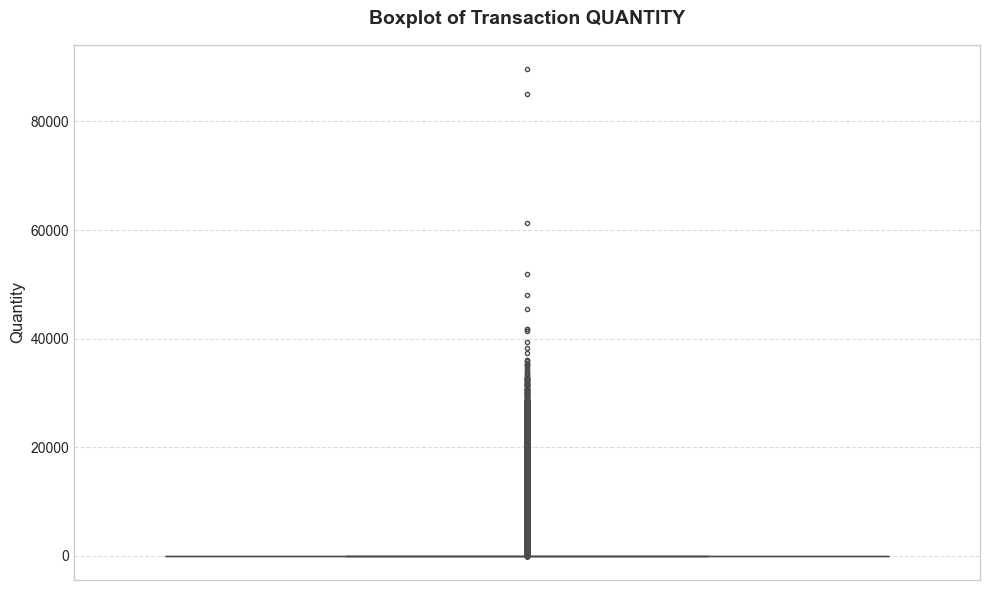

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- QUANTITY Outlier Analysis ---")

# 1. Calculate 99.9th percentile
quant_999 = transactions_cleaned['QUANTITY'].quantile(0.999)
print(f"99.9th Percentile of QUANTITY: {quant_999}")

# 2. Display top 10 highest quantity rows
print("\nTop 10 Rows with Highest QUANTITY:")
display(transactions_cleaned.nlargest(10, 'QUANTITY'))

# 3. Plot Boxplot (Static & Optimized for large data)
plt.figure(figsize=(10, 6))
sns.boxplot(y=transactions_cleaned['QUANTITY'], color='#4C72B0', fliersize=3)
plt.title('Boxplot of Transaction QUANTITY', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Quantity', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [57]:
print("--- High-Quantity Transactions Deep Dive (QUANTITY > 100) ---")

# 1. Filter transactions
high_qty_txns = transactions_cleaned[transactions_cleaned['QUANTITY'] > 100]

# 2. Merge with product table to get DEPARTMENT and COMMODITY_DESC
high_qty_merged = high_qty_txns.merge(
    product[['PRODUCT_ID', 'DEPARTMENT', 'COMMODITY_DESC']], 
    on='PRODUCT_ID', 
    how='left'
)

# 3. Group and aggregate
high_qty_summary = high_qty_merged.groupby(['DEPARTMENT', 'COMMODITY_DESC']).agg(
    txn_count=('BASKET_ID', 'count'),
    avg_sales_value=('SALES_VALUE', 'mean'),
    min_qty=('QUANTITY', 'min'),
    max_qty=('QUANTITY', 'max')
).reset_index()

# 4. Sort descending by count and display
high_qty_summary = high_qty_summary.sort_values('txn_count', ascending=False)
display(high_qty_summary)

--- High-Quantity Transactions Deep Dive (QUANTITY > 100) ---


,DEPARTMENT,COMMODITY_DESC,txn_count,avg_sales_value,min_qty,max_qty
0,KIOSK-GAS,COUPON/MISC ITEMS,20261,25.402742,103,89638
2,MISC SALES TRAN,COUPON/MISC ITEMS,2868,31.151028,103,85055
1,KIOSK-GAS,FUEL,6,48.048336,10393,30080
3,PRODUCE,CORN,1,24.000000,144,144


In [58]:
print("--- Additional Filtering (Department & Quantity Outliers) ---")

# 1. Find PRODUCT_IDs belonging to 'KIOSK-GAS' or 'MISC SALES TRAN'
exclude_depts = ['KIOSK-GAS', 'MISC SALES TRAN']
exclude_pids = product[product['DEPARTMENT'].isin(exclude_depts)]['PRODUCT_ID']

# 2. Filter out those PRODUCT_IDs and rows where QUANTITY > 150
transactions_cleaned = transactions_cleaned[
    (~transactions_cleaned['PRODUCT_ID'].isin(exclude_pids)) &
    (transactions_cleaned['QUANTITY'] <= 150)
]

# 3. Verify the final row count
print(f"Final row count of transactions_cleaned after additional filtering: {len(transactions_cleaned):,}")

--- Additional Filtering (Department & Quantity Outliers) ---
Final row count of transactions_cleaned after additional filtering: 2,548,770


## Step 3: Strategic Churn Labeling (Personalized Threshold)

In [59]:
# 1. Get unique purchase DAYs and calculate IPT
unique_purchases = transactions_cleaned[['household_key', 'DAY']].drop_duplicates().sort_values(['household_key', 'DAY'])
unique_purchases['prev_DAY'] = unique_purchases.groupby('household_key')['DAY'].shift(1)
unique_purchases['IPT'] = unique_purchases['DAY'] - unique_purchases['prev_DAY']

# 2 & 4. Group by household_key to calculate metrics & create customer_churn DataFrame
customer_churn = unique_purchases.groupby('household_key').agg(
    mean_IPT=('IPT', 'mean'),
    std_IPT=('IPT', 'std'),
    last_purchase_day=('DAY', 'max')
).reset_index()

# 3. Calculate global threshold
global_mean_IPT = unique_purchases['IPT'].mean()
global_std_IPT = unique_purchases['IPT'].std()
global_threshold = global_mean_IPT + 2 * global_std_IPT

# 5. Calculate personalized_threshold and fill NaNs
customer_churn['personalized_threshold'] = customer_churn['mean_IPT'] + 2 * customer_churn['std_IPT']
customer_churn['personalized_threshold'] = customer_churn['personalized_threshold'].fillna(global_threshold)

# 6. Calculate recency
customer_churn['recency'] = 711 - customer_churn['last_purchase_day']

# 7. Create the label is_churn
customer_churn['is_churn'] = (customer_churn['recency'] > customer_churn['personalized_threshold']).astype(int)

# 8. Print results
print(f"Global Fallback Threshold: {global_threshold:.2f} days\n")
print("Churn Value Counts:")
print(customer_churn['is_churn'].value_counts())
print("\nChurn Percentages:")
print(customer_churn['is_churn'].value_counts(normalize=True) * 100)

Global Fallback Threshold: 40.32 days

Churn Value Counts:
is_churn
0    2198
1     302
Name: count, dtype: int64

Churn Percentages:
is_churn
0    87.92
1    12.08
Name: proportion, dtype: float64


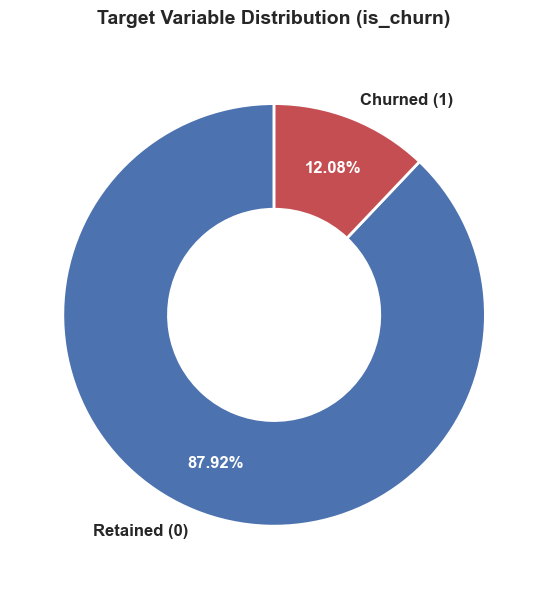

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare data
counts = customer_churn['is_churn'].value_counts().sort_index()
labels = ['Retained (0)', 'Churned (1)']
values = counts.values
colors = ['#4C72B0', '#C44E52']

# 2. Plotting Static Donut Chart
fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    values, 
    labels=labels, 
    colors=colors, 
    autopct='%1.2f%%',
    startangle=90, 
    pctdistance=0.75,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2),
    textprops=dict(size=12, weight='bold')
)

# Style the percentage text inside
for autotext in autotexts:
    autotext.set_color('white')

# 3. Layout and annotations
plt.title('Target Variable Distribution (is_churn)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## Step 4: Final Assembly & Export Deliverables

In [61]:
import os

# 1. Identify Valid Entities
valid_hhs = set(transactions_cleaned['household_key'].unique())
valid_pids = set(transactions_cleaned['PRODUCT_ID'].unique())

# 2. Sync All Tables
product_clean = product[product['PRODUCT_ID'].isin(valid_pids)]
hh_demographic_clean = hh_demographic[hh_demographic['household_key'].isin(valid_hhs)]
campaign_table_clean = campaign_table[campaign_table['household_key'].isin(valid_hhs)]
coupon_redempt_clean = coupon_redempt[coupon_redempt['household_key'].isin(valid_hhs)]
coupon_clean = coupon[coupon['PRODUCT_ID'].isin(valid_pids)]

# 3. Assemble Customer Base & Enrich Transactions
product_subset = product_clean[['PRODUCT_ID', 'DEPARTMENT', 'BRAND', 'COMMODITY_DESC']]
transactions_master = transactions_cleaned.merge(product_subset, on='PRODUCT_ID', how='left')

rfm_metrics = transactions_cleaned.groupby('household_key').agg(
    Frequency=('BASKET_ID', 'nunique'),
    Monetary=('SALES_VALUE', 'sum')
).reset_index()

# Merge F & M into Churn table (created in Step 3)
customer_base_labeled = customer_churn.merge(rfm_metrics, on='household_key', how='left')

# Merge Demographics
customer_base_labeled = customer_base_labeled.merge(hh_demographic_clean, on='household_key', how='left')

# Fill unknown for missing demographic info
demo_cols = ['AGE_DESC', 'MARITAL_STATUS_CODE', 'INCOME_DESC', 'HOMEOWNER_DESC', 
            'HH_COMP_DESC', 'HOUSEHOLD_SIZE_DESC', 'KID_CATEGORY_DESC']
customer_base_labeled[demo_cols] = customer_base_labeled[demo_cols].fillna('Unknown')

# 4. Export to Parquet
output_dir = '../Data/Processed/'
os.makedirs(output_dir, exist_ok=True)

customer_base_labeled.to_parquet(f'{output_dir}customer_base_labeled.parquet', index=False)
transactions_master.to_parquet(f'{output_dir}transactions_master.parquet', index=False)
campaign_table.to_parquet(f'{output_dir}campaign_table_clean.parquet', index=False)
campaign_desc.to_parquet(f'{output_dir}campaign_desc_clean.parquet', index=False)
coupon.to_parquet(f'{output_dir}coupon_clean.parquet', index=False)
hh_demographic_clean.to_parquet(f'{output_dir}demographics_imputed.parquet', index=False)
coupon_clean.to_parquet(f'{output_dir}coupon_clean.parquet', index=False)
coupon_redempt_clean.to_parquet(f'{output_dir}coupon_redempt_clean.parquet', index=False)

# 5. Final Report
print("--- Final Data Assembly & Export Summary ---")
print(f"Valid Households: {len(valid_hhs):,}")
print(f"Valid Products: {len(valid_pids):,}")
print(f"Successfully assembled and saved 7 files to {output_dir}")

--- Final Data Assembly & Export Summary ---
Valid Households: 2,500
Valid Products: 91,803
Successfully assembled and saved 7 files to ../Data/Processed/


## Step 5: Verification & Handoff

In [62]:
# Load the labeled customer base back into memory
verification_df = pd.read_parquet('../Data/Processed/customer_base_labeled.parquet')

# Print shape and display the first 3 rows
print(f"Verification Shape: {verification_df.shape}")
print("\nVerification Data Preview:")
display(verification_df.head(3))

Verification Shape: (2500, 16)

Verification Data Preview:


,household_key,mean_IPT,std_IPT,last_purchase_day,personalized_threshold,recency,is_churn,Frequency,Monetary,AGE_DESC,MARITAL_STATUS_CODE,INCOME_DESC,HOMEOWNER_DESC,HH_COMP_DESC,HOUSEHOLD_SIZE_DESC,KID_CATEGORY_DESC
0,1,8.506494,4.581494,706,17.669482,5,0,83,4310.160156,65+,A,35-49K,Homeowner,2 Adults No Kids,2,None/Unknown
1,10,142.750000,159.639959,685,462.029919,26,0,9,234.339996,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown
2,100,32.619048,24.499951,691,81.618950,20,0,23,1959.219971,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown


## Step 6: Technical Summary for Methodology Report

- **Data Scope**: 2,500 valid households, 91,803 valid products, and 711 days of transaction history.
- **Cleaning Impact**: 46,962 anomalous and outlier rows removed (~1.81% of raw data). This includes negative values, non-grocery departments (Gas/Misc), and wholesale quantities (>150).
- **Marketing Insight (Coupon Gap)**: Discovery of a massive 75.34% tracking gap (24.66% overlap) between actual coupon discounts applied at point-of-sale and the `coupon_redempt` log.
- **Labeling Logic**: Personalized churn threshold defined using $\mu + 2\sigma$ of Inter-Purchase Time, with a global fallback of 40.32 days.
- **Class Distribution**: 87.92% Retained (0) vs 12.08% Churn (1).
- **Final Deliverables**: 7 analysis-ready Parquet files exported to `Data/Processed/` (3 Core tables + 4 Marketing tables), completely synced and type-casted.